# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
import scipy.stats as stats
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numdifftools as nd
import pandas as pd
import sys
import astropy.constants as cst
import random
from matplotlib.patches import Patch
import zeus
from chainconsumer import ChainConsumer
from IPython.display import display, Math
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
! ls

__pycache__
animations
basket notebook.ipynb
basket.py
data
distribution2.png
fisher_matrix_analysis.py
fisher_matrix_analysis_notebook.ipynb
pictures
results


In [3]:
import fisher_matrix_analysis as fma
import basket as ba

# 1. LSST mock data

In [4]:
# fiducial parameters for fLCDM LSST data

H0=70
Mb=-19.3 

Om0_fCPL= 0.315
Ode0_fCPL=1-Om0_fCPL
w0_fCPL = -1.029
wa_fCPL= 0.21

# other parameters
c=float(np.array(cst.c.to('km/s')))
 
# fiducial cosmology
cosmo_fCPL=ac.Flatw0waCDM(H0=H0,Om0=Om0_fCPL,w0=w0_fCPL,wa=wa_fCPL)

In [5]:
# load data
LSST=np.load('data/LSST_fCPL.npz') #fiducial cosmology : kPEDE, binned data, no Gaussian noise added
z=LSST['z']
mb=LSST['mb']
sigma_stat=LSST['sigma_stat']
LSST.close()

# covariance matrix

# statistical error
rho = 0
std_matrix =  np.diag(sigma_stat)
corr_matrix = np.full((len(sigma_stat),len(sigma_stat)),rho)
np.fill_diagonal(corr_matrix,1.0)
Cov_stat_lsst = std_matrix @ corr_matrix @ std_matrix

# systematic error
Cov_sys_lsst=np.array(pd.read_table('data/covsys_lsst.csv',sep=',')).reshape((len(z),len(z))) 

# total covariance matrix
Cov_tot_lsst= Cov_sys_lsst + Cov_stat_lsst
Cov_inv_lsst=np.linalg.inv(Cov_tot_lsst)

In [6]:
# get original distribution form Ayan's original file
lsst_original=pd.read_csv('data/lsst_snIa_data.csv')
lsst_distribution=np.array(lsst_original.N)
N_tot = np.sum(lsst_distribution)
N_tot

5809

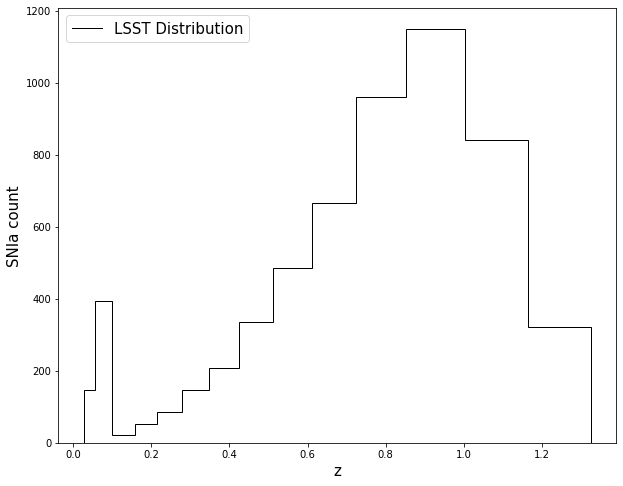

In [7]:
# Estimate bin edges

size=15

bin_edges = np.zeros(len(z) + 1)
bin_edges[1:-1] = (z[:-1] + z[1:]) / 2  # Midpoints as edges
bin_edges[0] = 2 * z[0] - bin_edges[1]  # Estimate first bin edge
bin_edges[-1] = 2 * z[-1] - bin_edges[-2]  # Estimate last bin edge

# plot
plt.figure(figsize=(10,8))
plt.stairs(lsst_distribution, bin_edges, label="LSST Distribution", color="black")
plt.xlabel("z",size=15)
plt.ylabel("SNIa count",size=15)
plt.legend(fontsize=15,loc='upper left')
plt.show()

## Optimise Fisher Area

In [8]:
n_iter = 50
n_sn = 50
epsilon = 1e-6
time_threshold=100 #s
list_of_distribution, list_of_C, list_of_area, list_of_cond_nb, list_of_fisher,list_of_Cov, list_of_det, list_of_Tr, list_of_norm = ba.optimise_fisher_area(lsst_distribution, 
                                                                                                                                                        n_sn, ba.T_lsst, n_iter, 
                                                                                                                                                        fma.chi2, [Om0_fCPL,w0_fCPL,wa_fCPL,Mb], 
                                                                                                                                                        ('fCPL'), H0, z, mb , Cov_stat_lsst, 
                                                                                                                                                        Cov_sys_lsst, epsilon=epsilon, 
                                                                                                                                                        time_threshold=time_threshold)

Optimizing Fisher Matrix:  50%|█████     | 25/50 [00:26<00:20,  1.21successful iter/s]c:\Users\cleam\Documents\Uni\PhD\Repositories\ConstrainingPowerLSST\fisher_matrix_analysis.py:254: RuntimeWarning: invalid value encountered in sqrt
  width,height = np.sqrt(sc.stats.chi2.ppf(1-alpha,2)*lambda1),np.sqrt(sc.stats.chi2.ppf(1-alpha,2)*lambda2)
Optimizing Fisher Matrix:  64%|██████▍   | 32/50 [02:46<01:33,  5.21s/successful iter]

Search for next successful iteration took 100.30s, exceeding 100.00s. Stopping optimization early.


In [9]:
np.savez('results/no_correlation', list_of_distribution = list_of_distribution,
        list_of_C = list_of_C,
        list_of_area = list_of_area,
        list_of_cond_nb = list_of_cond_nb,
        list_of_fisher= list_of_fisher,
        list_of_Cov = list_of_Cov, list_of_det = list_of_det, list_of_Tr = list_of_Tr, list_of_norm = list_of_norm)

In [10]:
results = np.load('results/no_correlation.npz')

# fisher evolution
list_of_distribution  = results['list_of_distribution']
list_of_C = results['list_of_C']
list_of_area = results['list_of_area']
list_of_cond_nb = results['list_of_cond_nb']
list_of_fisher = results['list_of_fisher']

# Cov evolution
list_of_Cov=results['list_of_Cov']
list_of_det=results['list_of_det']
list_of_Tr=results['list_of_Tr']
list_of_norm=results['list_of_norm']

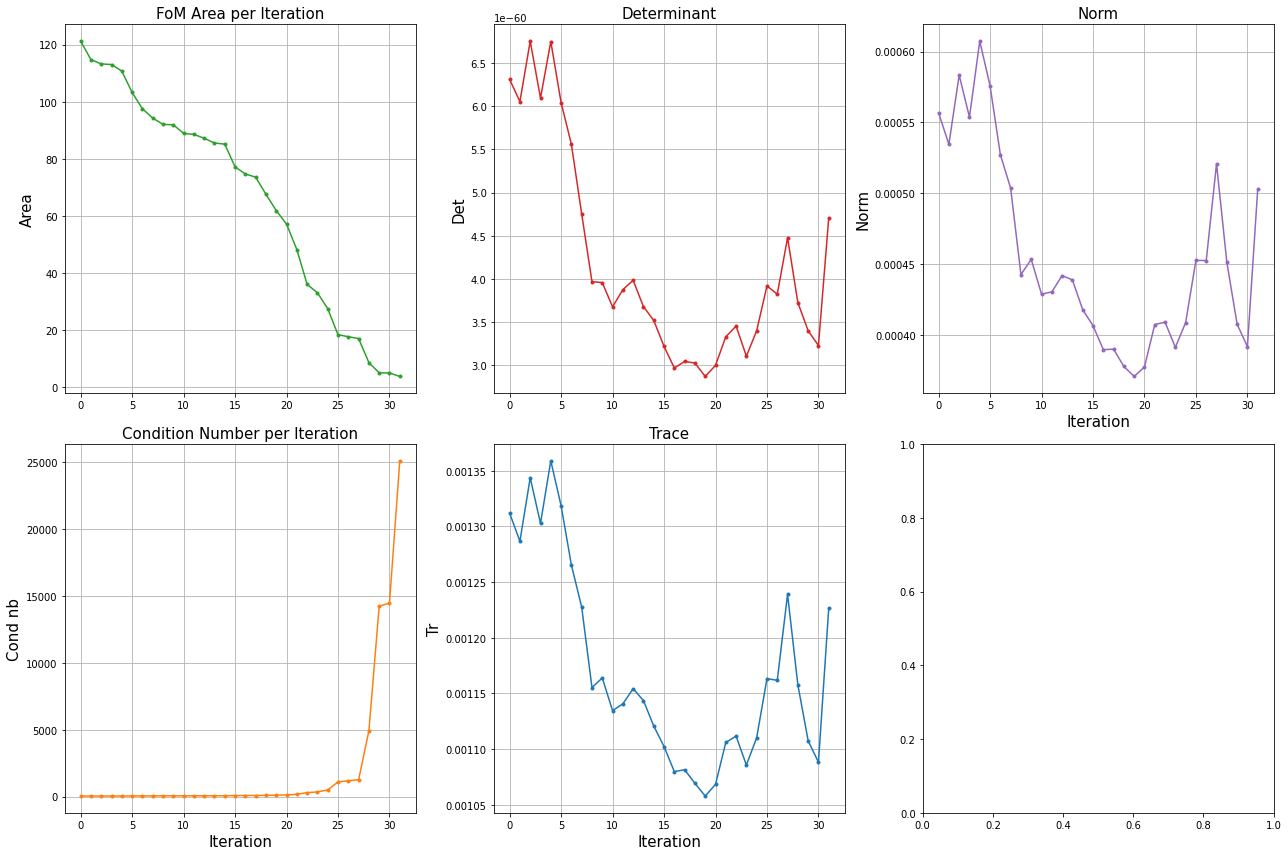

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Area
ax1=axs[0][0]
ax1.plot(list_of_area,marker='.', color='tab:green')
ax1.set_title("FoM Area per Iteration",size=size)
ax1.set_ylabel("Area",size=size)
ax1.grid(True)

# Plot 2: Condition Number
ax2=axs[1][0]
ax2.plot(list_of_cond_nb, marker='.', color='tab:orange')
ax2.set_title("Condition Number per Iteration",size=size)
ax2.set_xlabel("Iteration",size=size)
ax2.set_ylabel("Cond nb",size=size)
ax2.grid(True)


# Plot 3: Determinat of Cov_stat
ax3=axs[0][1]
ax3.plot(list_of_det, marker='.', color='tab:red')
ax3.set_title("Determinant",size=size)
ax3.set_ylabel("Det",size=size)
ax3.grid(True)

# Plot 4: Trace of Cov_stat
ax4=axs[1][1]
ax4.plot(list_of_Tr, marker='.', color='tab:blue')
ax4.set_title("Trace",size=size)
ax4.set_xlabel("Iteration",size=size)
ax4.set_ylabel("Tr",size=size)
ax4.grid(True)

# Plot 5: Norm of Cov_stat
ax4=axs[0][2]
ax4.plot(list_of_norm, marker='.', color='tab:purple')
ax4.set_title("Norm",size=size)
ax4.set_xlabel("Iteration",size=size)
ax4.set_ylabel("Norm",size=size)
ax4.grid(True)

plt.tight_layout()


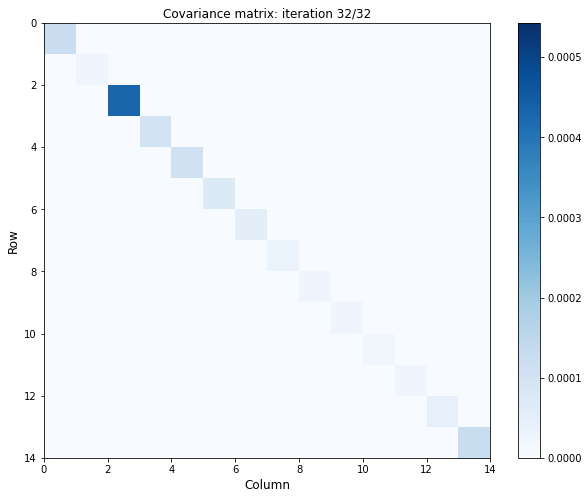

In [12]:
%matplotlib inline

# Assume Cov_difference is already defined and has shape (m, n, k)
m, n, k = list_of_Cov.shape

# Normalize for consistent color scale
vmin = list_of_Cov.min()
vmax = list_of_Cov.max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.Blues

# Create figure and axis with white background
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

# Axes and label styling
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')

# Meshgrid for pcolormesh
X, Y = np.meshgrid(np.arange(k + 1), np.arange(n + 1))

# Initial plot
quadmesh = ax.pcolormesh(X, Y, list_of_Cov[0], cmap=cmap, norm=norm)
ax.yaxis.set_inverted(True)
title = ax.set_title("Covariance matrix: iteration 0", color='black')

# Add a colorbar with black ticks and label
cbar = fig.colorbar(quadmesh, ax=ax)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Labels
ax.set_xlabel("Column", fontsize=12, color='black')
ax.set_ylabel("Row", fontsize=12, color='black')

# Update function
def update(frame):
    quadmesh.set_array(list_of_Cov[frame].flatten())
    title.set_text(f"Covariance matrix: iteration {frame + 1}/{m}")
    return quadmesh, title

# Create animation
anim = FuncAnimation(fig, update, frames=m, interval=200, blit=False)

# Save animation
# anim.save("animations/cov_animation_no_correlation.gif", fps=5, writer='pillow')

# Display animation
HTML(anim.to_jshtml())



In [13]:
Cov_difference=list_of_Cov[1:,:,:]-list_of_Cov[:-1,:,:]

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


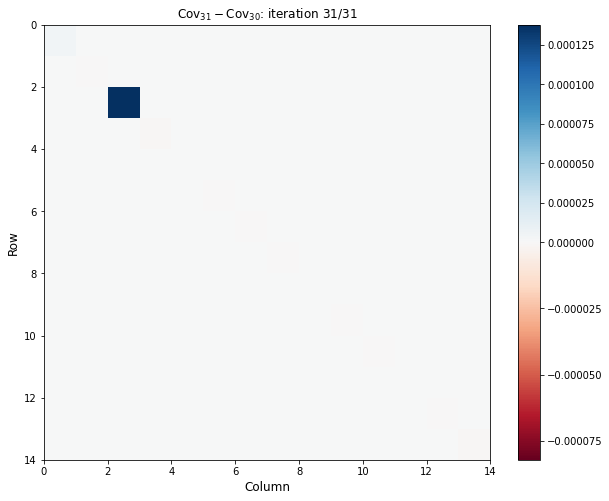

In [14]:
%matplotlib inline

# Assume Cov_difference is already defined and has shape (m, n, k)
m, n, k = Cov_difference.shape

# Normalize for consistent color scale
vmin = Cov_difference.min()
vmax = Cov_difference.max()
norm = mcolors.TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax)
cmap = cm.RdBu

# Create figure and axis with white background
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

# Axes and label styling
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')

# Meshgrid for pcolormesh
X, Y = np.meshgrid(np.arange(k + 1), np.arange(n + 1))

# Initial plot
quadmesh = ax.pcolormesh(X, Y, Cov_difference[0], cmap=cmap, norm=norm)
ax.yaxis.set_inverted(True)
title = ax.set_title(r"$Cov_{1}-Cov_{0}$: iteration 0", color='black')

# Add a colorbar with black ticks and label
cbar = fig.colorbar(quadmesh, ax=ax)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Labels
ax.set_xlabel("Column", fontsize=12, color='black')
ax.set_ylabel("Row", fontsize=12, color='black')

# Update function
def update(frame):
    quadmesh.set_array(Cov_difference[frame].flatten())
    title.set_text(rf"$\mathrm{{Cov}}_{{{frame+1}}} - \mathrm{{Cov}}_{{{frame}}}$: iteration {frame + 1}/{m}")

    return quadmesh, title

# Create animation
anim = FuncAnimation(fig, update, frames=m, interval=200, blit=False)


# Save animation
# anim.save("animations/cov_difference_animation_no_correlation.gif", fps=5, writer='pillow')


# Display animation
HTML(anim.to_jshtml())


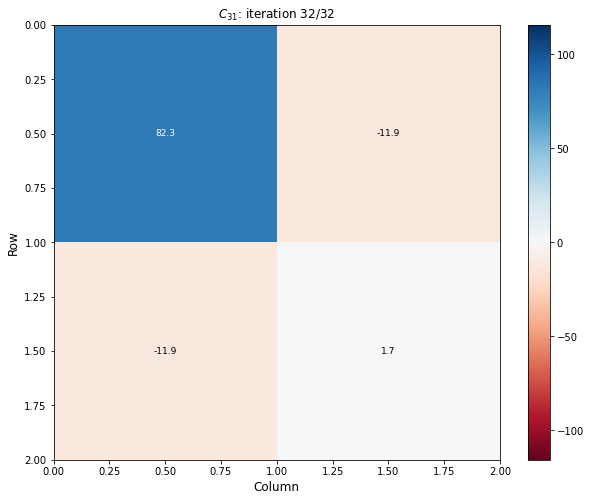

In [15]:
%matplotlib inline
# Assume list_of_C is already defined and has shape (m, n, k)
m, n, k = list_of_C.shape

# Normalize color scale symmetrically around 0
abs_max = np.max(np.abs(list_of_C))
norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
cmap = cm.RdBu

# Create figure and axis with white background
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

# Axes and label styling
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')

# Meshgrid for pcolormesh (must match shape of data + 1)
X, Y = np.meshgrid(np.arange(k + 1), np.arange(n + 1))

# Initial matrix
initial_matrix = list_of_C[0]
quadmesh = ax.pcolormesh(X, Y, initial_matrix, cmap=cmap, norm=norm)
ax.yaxis.set_inverted(True)
title = ax.set_title(r"$C_0$: iteration 0", color='black')

# Add a colorbar
cbar = fig.colorbar(quadmesh, ax=ax)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Axis labels
ax.set_xlabel("Column", fontsize=12, color='black')
ax.set_ylabel("Row", fontsize=12, color='black')

# Add text annotations (one per cell)
text_objects = []
for i in range(n):
    for j in range(k):
        txt = ax.text(j + 0.5, i + 0.5, f"{initial_matrix[i, j]:.1f}",
                      ha='center', va='center', color='black', fontsize=9)
        text_objects.append(txt)

# Update function for animation
def update(frame):
    data = list_of_C[frame]
    quadmesh.set_array(data.flatten())
    title.set_text(rf"$C_{{{frame}}}$: iteration {frame + 1}/{m}")
    
    # Update text annotations
    for i in range(n):
        for j in range(k):
            idx = i * k + j
            value = data[i, j]
            text_objects[idx].set_text(f"{value:.1f}")
            text_objects[idx].set_color('white' if abs(value) > abs_max / 2 else 'black')

    return [quadmesh, title] + text_objects

# Create animation
anim = FuncAnimation(fig, update, frames=m, interval=200, blit=False)

# save animation
# anim.save("animations/C_animation_no_correlation.gif", fps=5, writer='pillow')

# Display animation
HTML(anim.to_jshtml())


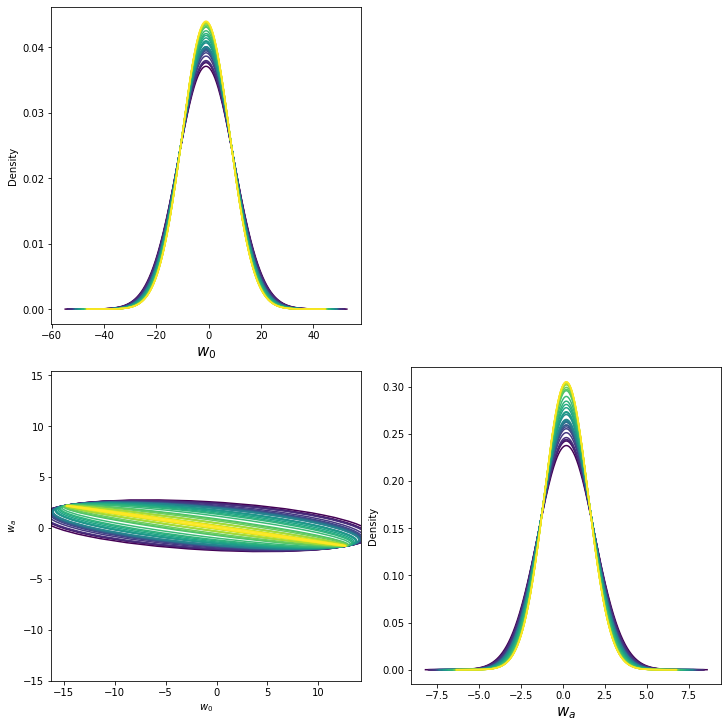

In [16]:
param_names = ['w0', 'wa']
param_labels = [r'$w_0$', r'$w_a$']
param_to_plot = ['w0', 'wa']
fiducial_param = [w0_fCPL, wa_fCPL]

N = len(list_of_fisher)  
cmap = cm.viridis  
colors = cmap(np.linspace(0, 1, N))

fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)

for i, fisher_matrix in enumerate(list_of_fisher):
    color = colors[i]
    fma.add_fisher_to_plot(
        fisher_matrix,
        fiducial_param=[w0_fCPL, wa_fCPL],
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color=color,
        filled=False,
        fontsize=size,
        param_labels=param_labels
    )


In [17]:
F_lsst = fma.fisher_matrix(fma.chi2, [Om0_fCPL,w0_fCPL,wa_fCPL,Mb], ('fCPL'), H0, z, mb, Cov_tot_lsst)
F_lsst_marginalised = fma.marginalize_fisher_matrix(F_lsst, ['w0','wa'], ['Om0','w0','wa','Mb'])
C = np.linalg.inv(F_lsst_marginalised)
area_lsst = fma.ellipse_parameters(C,0.32)[3]

In [18]:
list_of_fisher[0],[w0_fCPL, wa_fCPL],param_indices,param_labels

(array([[0.00984209, 0.02201004],
        [0.02201004, 0.40372893]]),
 [-1.029, 0.21],
 [0, 1],
 ['$w_0$', '$w_a$'])

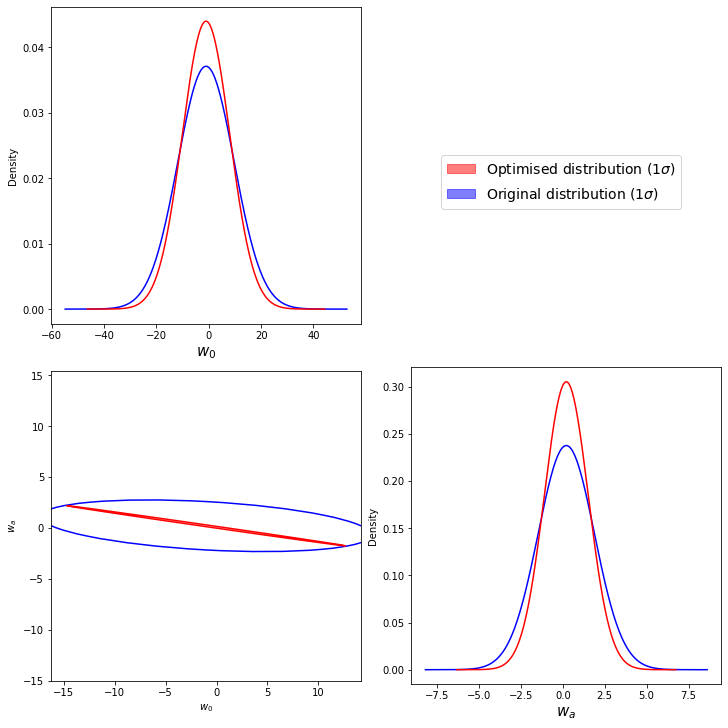

In [19]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
fma.add_fisher_to_plot(
        list_of_fisher[0],
        fiducial_param=[w0_fCPL, wa_fCPL],
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        fontsize=size,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        list_of_fisher[-1],
        fiducial_param=[w0_fCPL, wa_fCPL],
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        fontsize=size,
        param_labels=param_labels
    )

# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='red', edgecolor='red', alpha=0.5, label=r'Optimised distribution (1$\sigma$)'),
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)')]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)

# Show the final overlaid plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


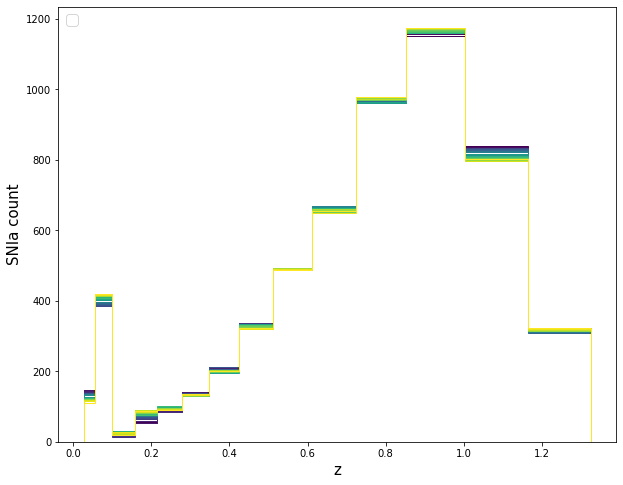

In [20]:
# plot
size=15

N = len(list_of_distribution)  
cmap = cm.viridis  
colors = cmap(np.linspace(0, 1, N))

plt.figure(figsize=(10,8))
for i, d in enumerate(list_of_distribution):
    color = colors[i]
    plt.stairs(d, bin_edges, color=color)
plt.xlabel("z",size=size)
plt.ylabel("SNIa count",size=size)
plt.legend(fontsize=size,loc='upper left')
plt.show()

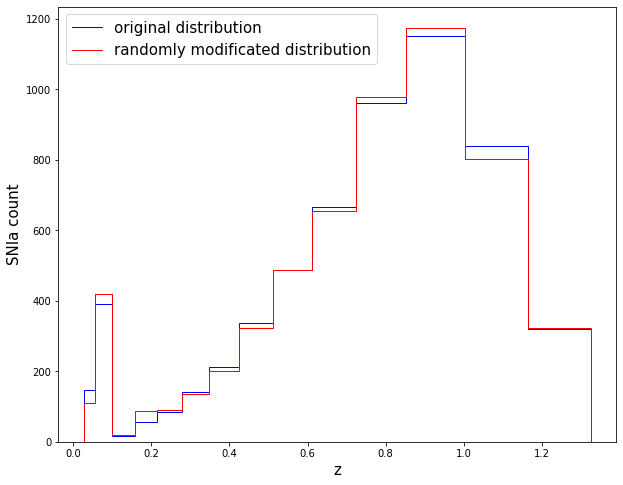

In [21]:
# plot
size=15
plt.figure(figsize=(10,8))
plt.stairs(list_of_distribution[0], bin_edges, color='blue',label='original distribution')
plt.stairs(list_of_distribution[-1], bin_edges, color='red',label='randomly modificated distribution')
plt.xlabel("z",size=size)
plt.ylabel("SNIa count",size=size)
plt.legend(fontsize=size,loc='upper left')
plt.show()

In [22]:
for i in range(0,len(list_of_distribution[0])):
    print(i,' bin: ' ,list_of_distribution[:,i])

0  bin:  [146 145 146 145 142 139 137 139 136 138 135 132 135 136 133 134 128 126
 122 124 120 124 121 120 118 121 119 118 120 118 115 111]
1  bin:  [392 392 392 387 391 389 390 385 388 391 392 395 396 396 402 406 406 402
 405 406 410 409 416 417 419 420 417 413 418 416 417 419]
2  bin:  [17 18 16 17 15 16 18 19 23 22 24 24 23 23 25 26 28 28 30 31 30 26 26 28
 26 22 22 18 22 26 28 19]
3  bin:  [55 54 54 59 64 64 64 68 70 75 78 73 73 79 77 77 80 79 76 76 78 78 77 81
 83 83 86 90 90 85 87 88]
4  bin:  [ 85  89  86  86  85  92  92  96  92  92  90  92  92  94  93  97  97  99
  99 100 100 101  97  95  93  96  95  93  93  94  91  91]
5  bin:  [142 138 142 139 135 135 134 134 138 137 135 137 137 135 134 135 136 133
 133 133 130 129 134 136 136 131 135 137 135 133 134 135]
6  bin:  [212 210 212 210 207 205 205 207 212 206 207 203 200 198 198 197 200 199
 196 197 198 200 198 199 199 200 202 204 201 200 201 202]
7  bin:  [336 336 336 336 335 336 331 329 325 324 324 324 326 326 330 329 332 335
 3

# 2. Roman data

In [23]:
#for flat CPL roman
roman_fiducial={
    'H0':73,
    'Mb':-19.3,
    'Om0':0.315,
    'w0':-1.029,
    'wa':0.21
}

In [24]:
ROMAN=np.load('data/NGR_fCPL.npz') 
z_roman=ROMAN['z']
mb_roman=ROMAN['mb']
sigma_roman=ROMAN['sigma']
Cov_tot_roman=np.diag(sigma_roman)
ROMAN.close()

ROMAN_DIST = np.load('data/roman_data_dist.npz')
original_dist_roman = ROMAN_DIST['SN_count']
bin_edges_roman = ROMAN_DIST['bin_edges']
z_bins_roman = ROMAN_DIST['z_bins']
ROMAN_DIST.close()

In [25]:
z_roman.shape

(16,)

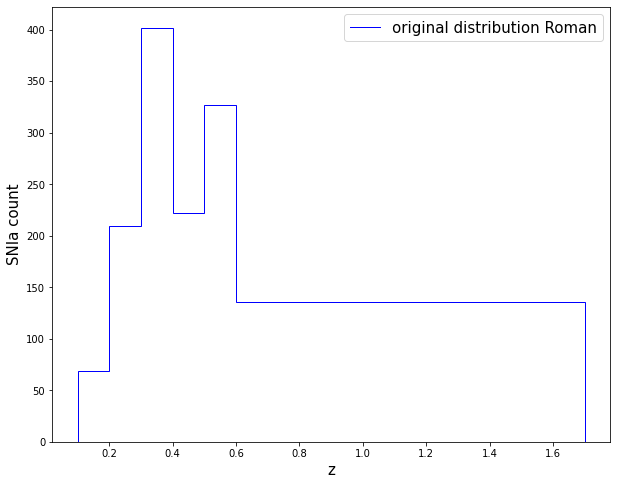

In [26]:
# plot
size=15
plt.figure(figsize=(10,8))
plt.stairs(original_dist_roman, bin_edges_roman, color='blue',label='original distribution Roman')
plt.xlabel("z",size=size)
plt.ylabel("SNIa count",size=size)
plt.legend(fontsize=size,loc='upper right')
plt.show()

In [27]:
F_roman = fma.fisher_matrix(fma.chi2, [roman_fiducial['Om0'],roman_fiducial['w0'],roman_fiducial['wa'],roman_fiducial['Mb']], ('fCPL'),  
                            roman_fiducial['H0'], z_roman, mb_roman, Cov_tot_roman)
F_roman_marginalised = fma.marginalize_fisher_matrix(F_roman, ['w0','wa'], ['Om0','w0','wa','Mb'])
C_roman = fma.eigenvalues_clipping(np.linalg.inv(F_roman_marginalised))
area_lsst = fma.ellipse_parameters(C_roman,0.32)[3]

[]

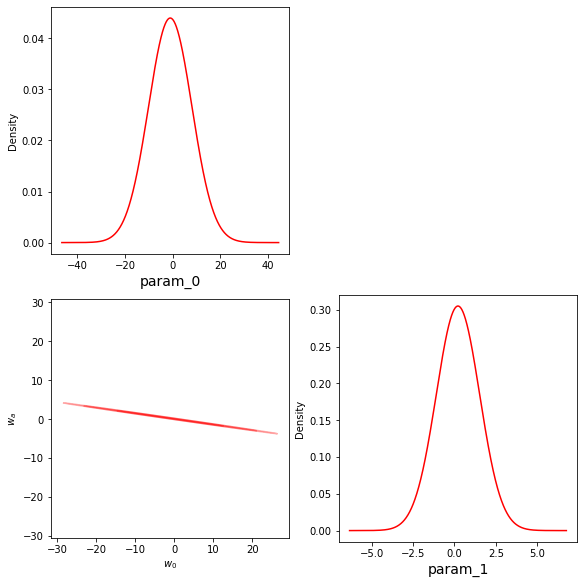

In [28]:
fig, gs, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(param_names, param_to_plot, param_labels=param_labels)

fma.add_fisher_to_plot(
    fisher_matrix,
    fiducial_param,
    axs_2d,
    axs_1d,
    param_indices,
    alpha_values=[0.32, 0.05, 0.01],
    color="red",
    filled=True,
    fontsize=14,
    param_labels=None
)
plt.plot()

In [29]:
n_iter = 50
n_sn = 50
epsilon = 1e-6
time_threshold=100 #s
list_of_distribution_roman, list_of_C_roman, list_of_area_roman, list_of_cond_nb_roman, list_of_fisher_roman,list_of_Cov_roman, list_of_det_roman, list_of_Tr_roman, list_of_norm_roman = ba.optimise_fisher_area(original_dist_roman, 
                                                                                                                                                        n_sn, ba.T_ngrt, n_iter, 
                                                                                                                                                        fma.chi2, [roman_fiducial['Om0'],roman_fiducial['w0'],roman_fiducial['wa'],roman_fiducial['Mb']], 
                                                                                                                                                        ('fCPL'), roman_fiducial['H0'], z_roman, mb_roman , Cov_tot_roman, 
                                                                                                                                                        np.zeros_like(Cov_tot_roman), epsilon=epsilon, 
                                                                                                                                                        time_threshold=time_threshold)

c:\Users\cleam\Documents\Uni\PhD\Repositories\ConstrainingPowerLSST\fisher_matrix_analysis.py:254: RuntimeWarning: invalid value encountered in sqrt
  width,height = np.sqrt(sc.stats.chi2.ppf(1-alpha,2)*lambda1),np.sqrt(sc.stats.chi2.ppf(1-alpha,2)*lambda2)
Optimizing Fisher Matrix:   0%|          | 0/50 [01:40<?, ?successful iter/s]

Search for next successful iteration took 100.34s, exceeding 100.00s. Stopping optimization early.
